In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

BASE_DIR = Path("../").resolve()
DATA_PATH = BASE_DIR / "data" / "preprocessed_data.csv"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

In [3]:
df = pd.read_csv(" E:\OTRAS-PLATFORM\otras-platform\ml-service\data\preprocessed_data.csv")

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\O'
C:\Users\satya\AppData\Local\Temp\ipykernel_6784\2816119102.py:1: SyntaxWarning: invalid escape sequence '\O'
  df = pd.read_csv(" E:\OTRAS-PLATFORM\otras-platform\ml-service\data\preprocessed_data.csv")
C:\Users\satya\AppData\Local\Temp\ipykernel_6784\2816119102.py:1: SyntaxWarning: invalid escape sequence '\O'
  df = pd.read_csv(" E:\OTRAS-PLATFORM\otras-platform\ml-service\data\preprocessed_data.csv")


NameError: name 'pd' is not defined

In [12]:
FEATURE_COLUMNS = [
    "aptitude_score",
    "subject_score",
    "time_management_score",
    "mock_average_score",
    "consistency_score"
]

TARGET_COLUMN = "readiness_score"

X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=8, n_estimators=200, random_state=42)

In [16]:
preds = model.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 1.6939006614754866
R2: 0.9452000430658744


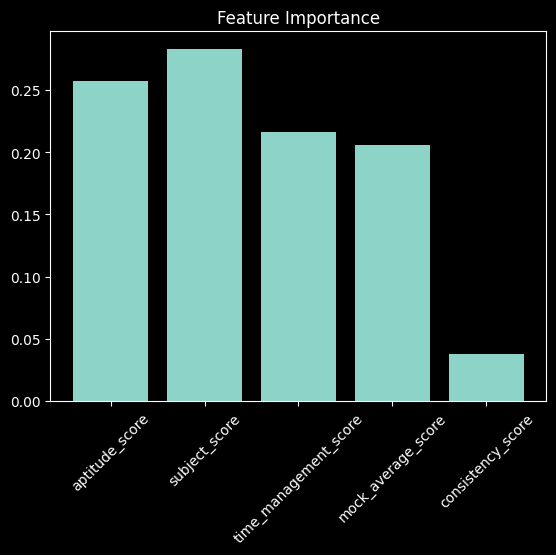

In [17]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.figure()
plt.bar(FEATURE_COLUMNS, importances)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [18]:
joblib.dump(model, MODEL_DIR / "readiness_model.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
